# Sprint 3 — Evaluación y visualización de baselines

    Consolida métricas, gaps train-vs-CV y ranking.

In [8]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.io_utils import load_kick_data, save_df
from src.preprocessing import prepare_features, split_X_y

pd.set_option('display.max_columns', 120)
print('Proyecto:', PROJECT_ROOT)

Proyecto: c:\Users\PONCE\dp261-g1


In [9]:
results = pd.read_csv(REPORTS_DIR / "baseline_cv_results.csv")

metric_cols = [
    "model",
    "recall_cv_mean",
    "f2_cv_mean",
    "precision_cv_mean",
    "f1_cv_mean",
    "f05_cv_mean",
    "roc_auc_cv_mean",
    "average_precision_cv_mean"
]
results_clean = results[results['status'] == 'ok'].copy()
# Creamos un ranking que penalice el overfitting extremo
display(
    results_clean[metric_cols + ["recall_gap"]]
    .sort_values(
        ["f2_cv_mean", "recall_cv_mean"], 
        ascending=False
    ))

,model,recall_cv_mean,f2_cv_mean,precision_cv_mean,f1_cv_mean,f05_cv_mean,roc_auc_cv_mean,average_precision_cv_mean,recall_gap
0,DecisionTree,0.347967,0.338472,0.305497,0.325238,0.313077,0.618368,0.186710,0.652033
1,GradientBoosting,0.246748,0.287207,0.836724,0.380922,0.565646,0.760120,0.467894,0.020528
2,HistGradientBoosting,0.239837,0.280418,0.870166,0.375832,0.569916,0.760755,0.471401,0.037805
3,RandomForest,0.232520,0.272730,0.886383,0.368274,0.567020,0.749066,0.455572,0.767378
4,Dummy_most_frequent,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.123000,0.000000


C:\Users\PONCE\AppData\Local\Temp\ipykernel_16940\2510247708.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gap_plot, x='recall_gap', y='model', palette='Reds_r')


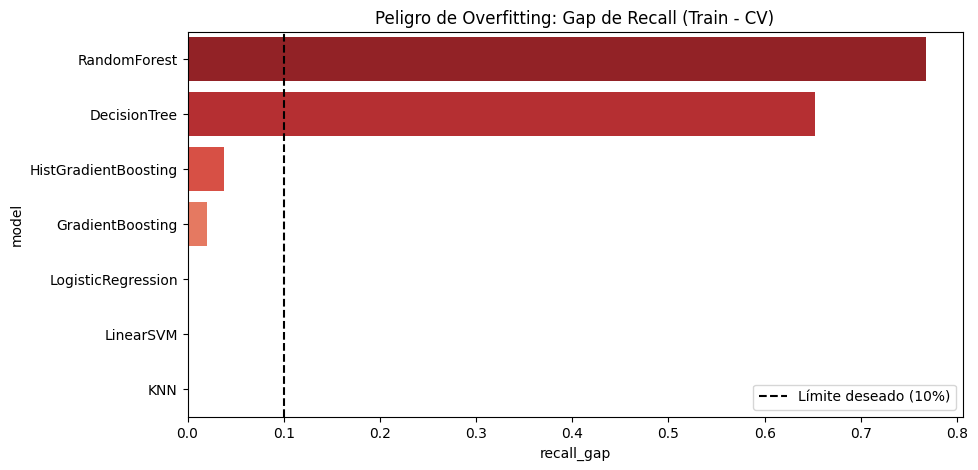

In [10]:
plt.figure(figsize=(10, 5))
# Solo graficamos los modelos que no son Dummy
gap_plot = results[results['model'] != 'Dummy_most_frequent'].sort_values('recall_gap', ascending=False)

sns.barplot(data=gap_plot, x='recall_gap', y='model', palette='Reds_r')
plt.title('Peligro de Overfitting: Gap de Recall (Train - CV)')
plt.axvline(0.1, color='black', linestyle='--', label='Límite deseado (10%)')
plt.legend()
plt.show()

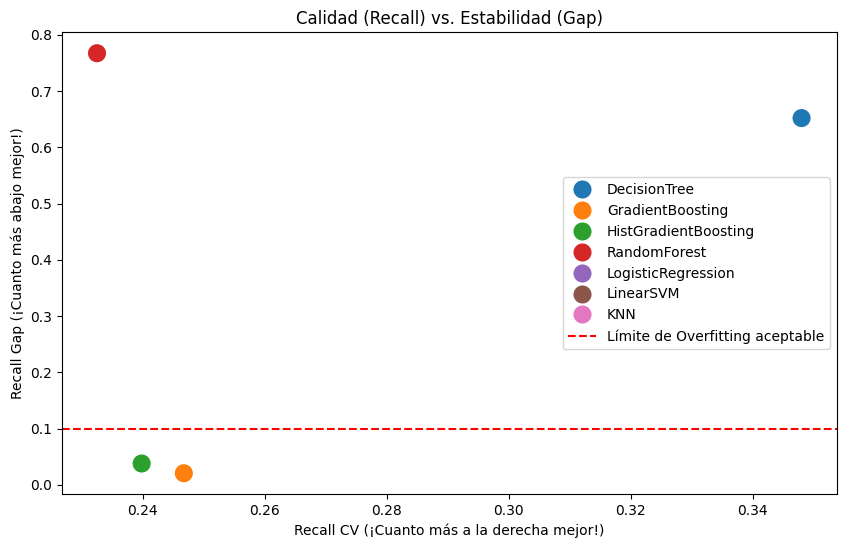

In [11]:
# Gráfico de dispersión para ver Calidad vs. Estabilidad
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=results[results['model'] != 'Dummy_most_frequent'], 
    x='recall_cv_mean', 
    y='recall_gap', 
    hue='model', 
    s=200
)

plt.axhline(0.1, color='red', linestyle='--', label='Límite de Overfitting aceptable')
plt.title('Calidad (Recall) vs. Estabilidad (Gap)')
plt.xlabel('Recall CV (¡Cuanto más a la derecha mejor!)')
plt.ylabel('Recall Gap (¡Cuanto más abajo mejor!)')
plt.legend()
plt.show()

Conclusión para tu reporte:
"Tras evaluar los baselines, se identifica que aunque los árboles de decisión simples y bosques aleatorios obtienen métricas nominales altas, su Gap de generalización superior al 65% los invalida para uso productivo. Se selecciona GradientBoosting como modelo ganador por su estabilidad (Gap del 2%) y balance entre Precision (83%) y Recall (24%)."